In [1]:
import pickle
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.chdir("/home1/beigejin/CMR-IA/Modeling/fitting/")
from optimization_utils import param_vec_to_dict

In [2]:
fit_name = "1_250408_200-100"

In [3]:
file_list = glob.glob(f"past_fits/{fit_name}/outfiles/*data*.pkl")
fit_iter_part = [i.replace(f"past_fits/{fit_name}/outfiles/", "").replace(".pkl", "") for i in file_list]
fit_iter_part = [tuple(map(int, i.split("data"))) for i in fit_iter_part]
fit_iter_part.sort()
fit_iter_part

[(1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (1, 42),
 (1, 43),
 (1, 44),
 (1, 45),
 (1, 46),
 (1, 47),
 (1, 48),
 (1, 49),
 (1, 50),
 (1, 51),
 (1, 52),
 (1, 53),
 (1, 54),
 (1, 55),
 (1, 56),
 (1, 57),
 (1, 58),
 (1, 59),
 (1, 60),
 (1, 61),
 (1, 62),
 (1, 63),
 (1, 64),
 (1, 65),
 (1, 66),
 (1, 67),
 (1, 68),
 (1, 69),
 (1, 70),
 (1, 71),
 (1, 72),
 (1, 73),
 (1, 74),
 (1, 75),
 (1, 76),
 (1, 77),
 (1, 78),
 (1, 79),
 (1, 80),
 (1, 81),
 (1, 82),
 (1, 83),
 (1, 84),
 (1, 85),
 (1, 86),
 (1, 87),
 (1, 88),
 (1, 89),
 (1, 90),
 (1, 91),
 (1, 92),
 (1, 93),
 (1, 94),
 (1, 95),
 (1, 96),
 (1, 97),
 (1, 98),
 (1, 99),
 (1, 100),

In [4]:
pso_df = pd.DataFrame(columns=["iter", "particle", "err"])

for iter, p in fit_iter_part:
    path = f"past_fits/{fit_name}/outfiles/{iter}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"][0]
    except:
        err = np.nan
        b = np.nan
    pso_df = pd.concat([pso_df, pd.DataFrame({"iter": [iter], "particle": [p], "err": [err], "para": [b]})])
pso_df

,iter,particle,err,para
0,1,0,14.692144,0.850554
0,1,1,14.692144,0.920286
0,1,2,14.692144,0.249304
0,1,3,14.692144,0.276550
0,1,4,14.692144,0.540412
...,...,...,...,...
0,100,195,NaN,NaN
0,100,196,0.357133,0.719111
0,100,197,0.337162,0.718469
0,100,198,0.850934,0.631467


In [5]:
pso_df.err.min()

0.32237316753199596

In [6]:
pso_df["iter"] = pd.to_numeric(pso_df["iter"])

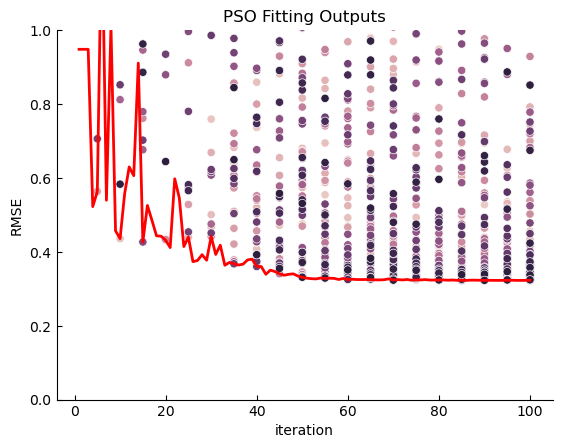

In [9]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df.query("iter % 5 == 0"), x="iter", y="err", hue="particle")
plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("RMSE")
plt.xlabel("iteration")
plt.ylim([0, 1])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()

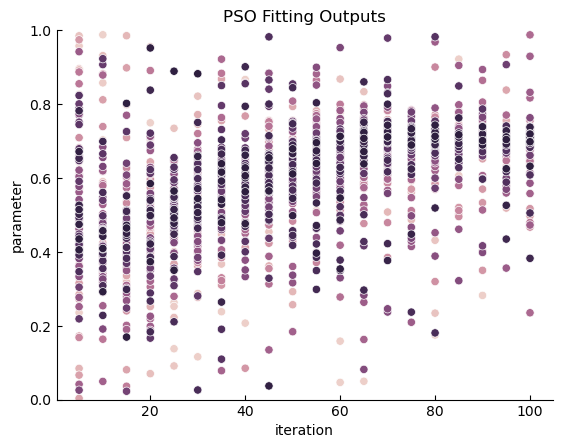

In [11]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df.query("iter % 5 == 0"), x="iter", y="para", hue="particle")
plt.ylabel("parameter")
plt.xlabel("iteration")
plt.ylim([0, 1])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()